# Advertising Benchmark

Goal: measure whether MF-REINFORCE learns advertising policies that increase the informed/customer population while controlling advertising cost.

**Environment Basics**

- State space: $\mathcal{X}=\{N,C\}$, encoded as `{0, 1}` for non-customer and customer.
- Action space: $\mathcal{A}=\{NO\_AD,AD\}$, encoded as `{0, 1}`.
- Population law: $\mu_t=(1-p_t,p_t)$, where $p_t=\mu_t(C)$ is the customer fraction.
- Policy input: normalized time and current customer fraction $p_t$; the policy outputs the advertisement probability.
- Main task: increase $p_t$ quickly, but avoid paying advertising cost when organic/current adoption is already high.

The finite-state population follows

$$
\mu_{t+1}(y)=\sum_x \mu_t(x)\sum_a \pi_\theta(a\mid x,\mu_t)P(y\mid x,a,\mu_t),
$$

and the reported value is the discounted population reward

$$
J(\theta)=\sum_{t=0}^{T}\gamma^t\sum_x \mu_t(x)r(x,a_t,\mu_t),
\qquad
r(x,a,\mu)=x-c_{ad}a.
$$

The main application statistic is the customer fraction $p_t=\mu_t(1)$ together with cumulative population gain and advertising expenditure.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from mfc.experiments import notebook_helpers as nh

ENV_NAME = "advertising"
BASE_DIR = ROOT / "runs" / "extended_benchmark_bundles" / ENV_NAME
PRESET = "mid"
QUICK = PRESET == "mid"
RUN_MISSING = True
FORCE_REBUILD = False
EXTENDED = True

In [2]:
bundle = (
    nh.ensure_discrete_benchmark_bundle(ENV_NAME, BASE_DIR, quick=QUICK, force=FORCE_REBUILD, extended=EXTENDED, preset=PRESET)
    if RUN_MISSING
    else nh.bundle_paths(ENV_NAME, BASE_DIR)
)
bundle

{'env': 'advertising',
 'base_dir': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/advertising'),
 'train': {'simplex': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/advertising/train/advertising_simplex'),
  'logits': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/advertising/train/advertising_logits')},
 'application': {'simplex': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/advertising/application/advertising_simplex'),
  'logits': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/advertising/application/advertising_logits')},
 'diagnostics': {'simplex': {'perturbation': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/advertising/diagnostics/advertising_simplex_perturbation'),
   'functional_law': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/advertising/diagnostics/advertising_simplex_functional_

## Figure Coverage

Goal: show which requested results from `docs/figures.md` are currently produced by this notebook and which artifacts support them.

The tables are an audit layer, not an estimator. A row maps a desired result family to the command or study that generates its data and to the notebook helper that renders it.

In [3]:
nh.figure_checklist(ENV_NAME)

,figure_family,command_or_study,files,notebook_section
0,perturbation_geometry,diagnose-perturbation,"diagnostics.csv, perturbation_samples.csv",universal diagnostics
1,functional_law,diagnose-functional-law,"diagnostics.csv, signature_samples.csv, functi...",universal diagnostics
2,score_validation,score-validation,"diagnostics.csv, score_coordinates.csv, score_...",universal diagnostics
3,gradient_validation,diagnose-gradient,"diagnostics.csv, gradient_samples.csv, gradien...",universal diagnostics
4,sensitivity_validation,diagnose-sensitivity,"diagnostics.csv, sensitivity_samples.csv",universal diagnostics
5,horizon_scaling,horizon-scaling,"grid_metrics.csv, diagnostics.csv",study sweeps
6,budget_allocation,budget-allocation,"grid_metrics.csv, diagnostics.csv",study sweeps
7,particle_approximation,particle-approximation,"grid_metrics.csv, diagnostics.csv",study sweeps
8,particle_transfer,particle-transfer,"diagnostics.csv, optimization_history.csv",study sweeps
9,ablation,ablation,"grid_metrics.csv, diagnostics.csv",study sweeps


In [4]:
nh.figure_coverage_matrix(ENV_NAME)

,figure_or_result,status,notebook_helper,artifact
0,"perturbation mean, bands, and empirical slopes",ready,"plot_perturbation_geometry, plot_perturbation_...",diagnostics/*_perturbation/diagnostics.csv
1,finite-state d_TV perturbation calibration and...,ready,"perturbation_tv_comparison_table, plot_perturb...","diagnostics/*_perturbation/diagnostics.csv, di..."
2,functional-law signature summaries,ready,"plot_functional_law, plot_functional_signature...",diagnostics/*_functional_law/diagnostics.csv
3,"functional-law histograms, pair plots, Q-Q plots",ready,plot_functional_sample_diagnostics,diagnostics/*_functional_law/signature_samples...
4,"score mean, variance, lambda^2 variance, coord...",ready,"plot_score_validation, plot_score_coordinate_d...",diagnostics/*_score/*.csv
5,"gradient bias, variance, MSE, cosine, norm, de...",ready,"plot_gradient_validation, plot_gradient_error_...",diagnostics/*_gradient/diagnostics.csv
6,coordinatewise gradient scatter and CI coverage,ready,plot_gradient_coordinate_diagnostics,diagnostics/*_gradient/gradient_coordinates.cs...
7,sensitivity error vs time/eta and heatmap,ready,"plot_sensitivity_validation, plot_sensitivity_...",diagnostics/*_sensitivity/diagnostics.csv
8,budget allocation heatmap and runtime Pareto,ready,"plot_budget_and_horizon, plot_budget_pareto",studies/budget_allocation/*.csv
9,horizon scaling,ready,plot_budget_and_horizon,studies/horizon_scaling/*.csv


## Training: Simplex vs Logits

Goal: compare the optimization traces of the two finite-state perturbation geometries.

The value/objective plot estimates $J(\theta_k)$ at training episode $k$. The gradient plot tracks $\|\widehat g_k\|_2$, where $\widehat g_k$ is the MF-REINFORCE gradient estimate used by Adam.

Simplex uses affine law perturbations on the simplex; logits uses logistic-normal perturbations in logit coordinates. The curves should be compared using the same saved train/evaluation budget.

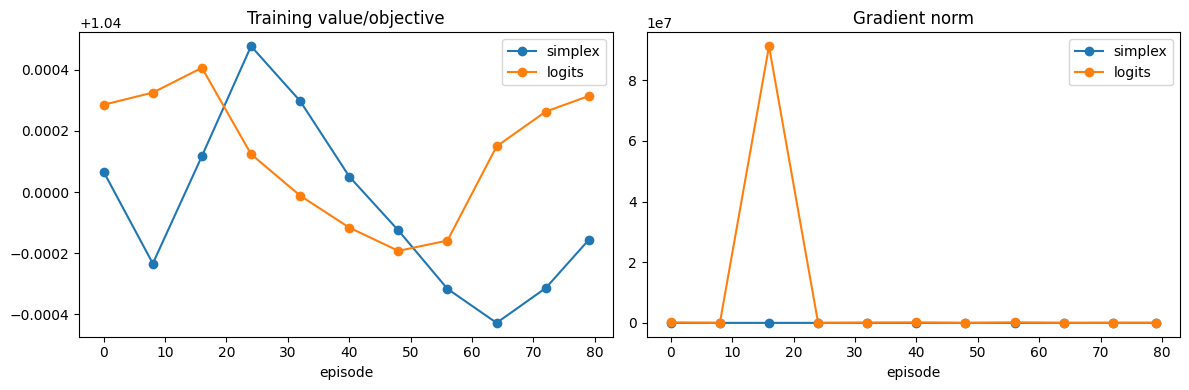

In [5]:
histories = nh.load_training_histories(bundle)
nh.plot_training_comparison(histories)

## Application Diagnostics

Goal: show whether the policy creates adoption/customer growth efficiently.

Reference: the table and dashed curves use the finite-horizon dynamic-programming oracle $q_t^*(p)$ on a customer-fraction grid; the policy heatmap also reports the infinite-horizon threshold reference when available.

The key curve is

$$
p_t=\mu_t(1),
$$

with horizontal target levels at 50% and 80%. The objective decomposition compares cumulative population gain with cumulative advertising cost, and the finite-population panel reports the approximation gap as particle count changes.

,algorithm,reference_kind,learned_value,reference_value,reference_value_gap
0,simplex,finite_horizon_dp_oracle,1.039843,1.073242,0.033399
1,logits,finite_horizon_dp_oracle,1.040314,1.073242,0.032928


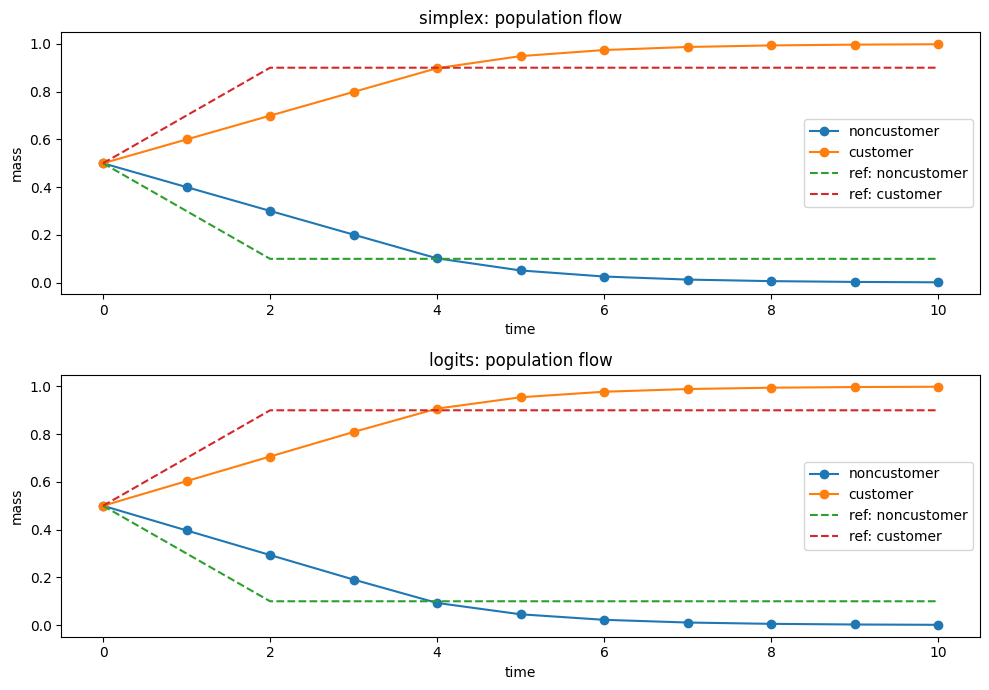

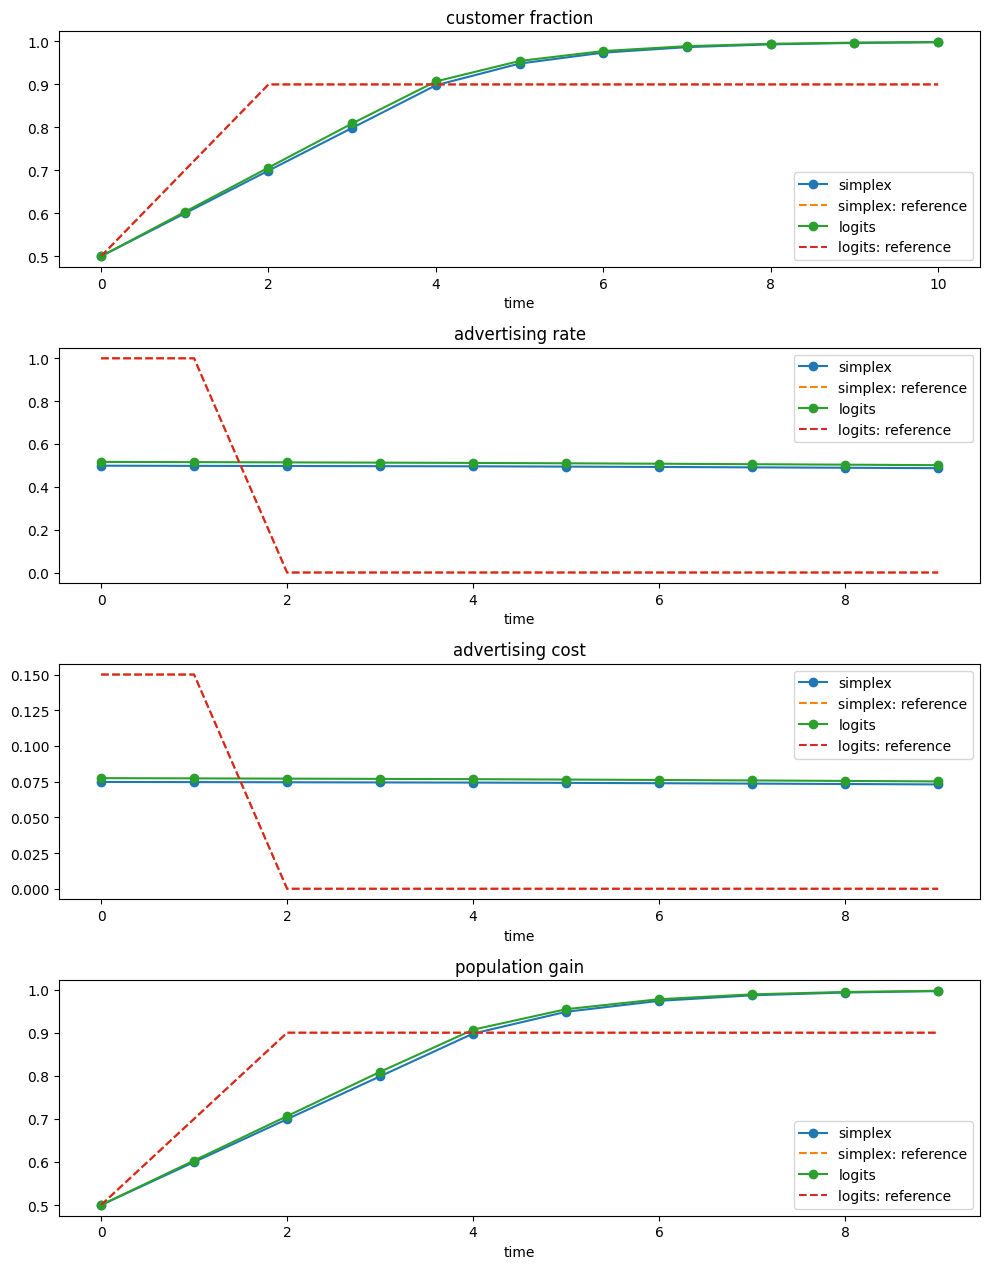

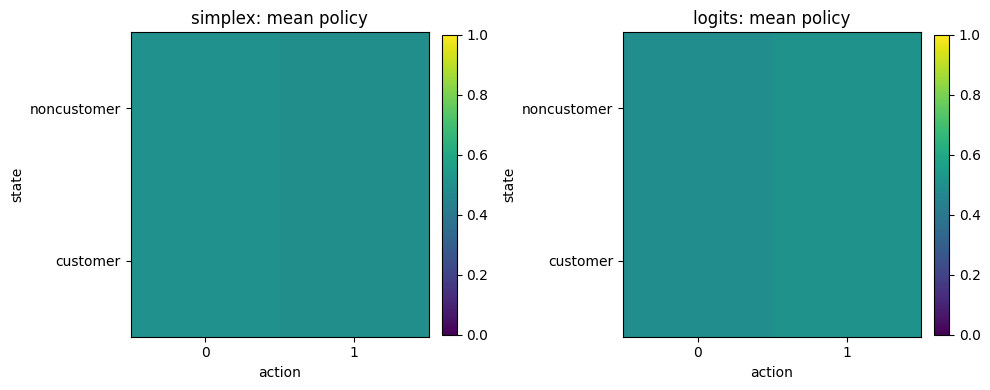

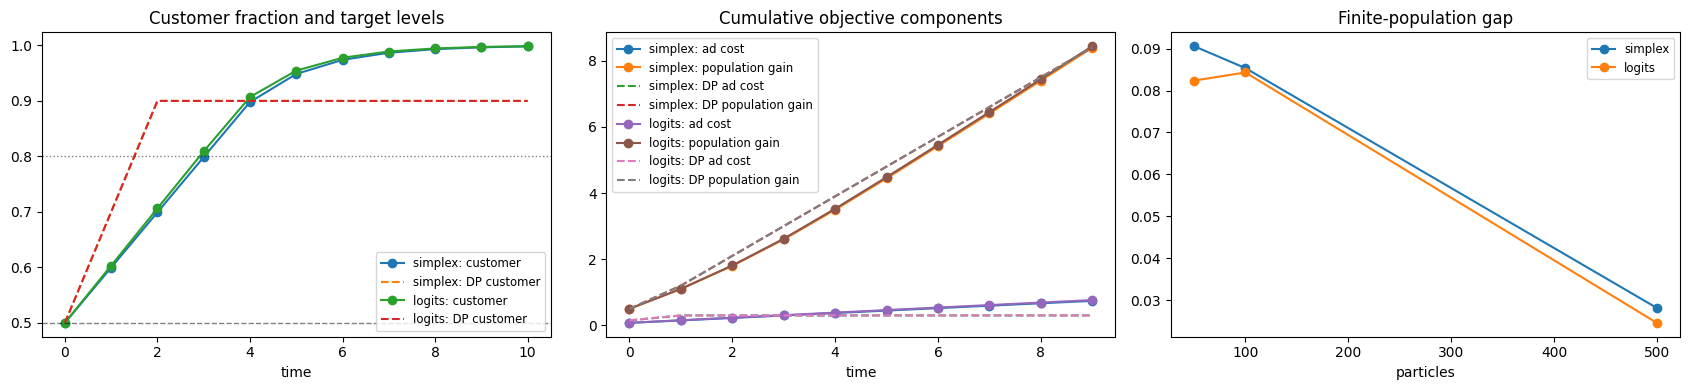

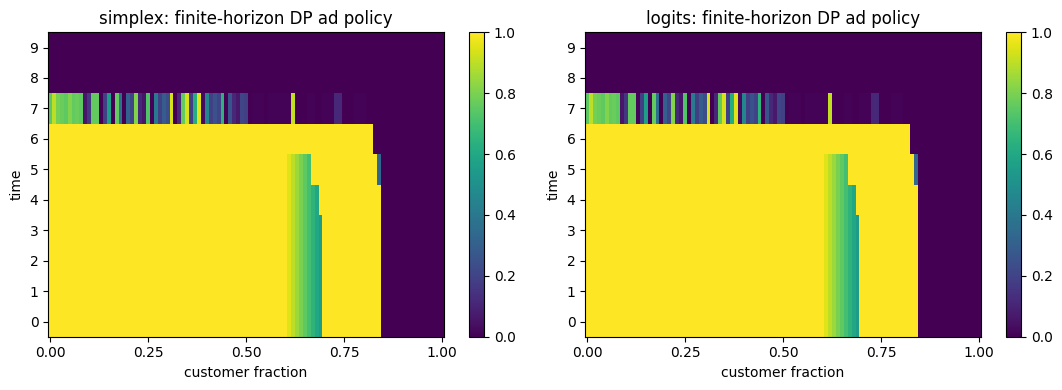

In [6]:
application = nh.load_application_data(bundle)
display(nh.reference_solution_table(ENV_NAME, application))
nh.plot_population_flow(application, ENV_NAME)
nh.plot_time_metrics(application, ENV_NAME)
nh.plot_policy_heatmaps(application, ENV_NAME)
nh.plot_discrete_application_details(application, ENV_NAME)

## Universal Diagnostics

Goal: validate the estimator chain before interpreting optimization performance.

The perturbation plots measure empirical geometry,

$$
d(M^\lambda,\mu),
$$

including quantile bands and local log-log slopes. The functional-law plots study

$$
\Gamma(M^\lambda)=(F_1(M^\lambda),\ldots,F_k(M^\lambda)),
\qquad
\frac{\Gamma(M^\lambda)-\Gamma(\mu)}{\lambda},
$$

which is the induced law of population signatures. The score plots check

$$
S_{t,\lambda}^\theta=\nabla_\theta\log q_{t,\lambda}^\theta(M_t),
\qquad \mathbb{E}[S_{t,\lambda}^\theta]\approx 0,
$$

and the gradient plots report bias, variance, MSE, norm ratio, and cosine agreement for an estimator $\widehat g$ against an oracle or reference gradient $g$:

$$
\operatorname{MSE}=\mathbb{E}\|\widehat g-g\|_2^2,
\qquad
\cos(\widehat g,g)=\frac{\widehat g\cdot g}{\|\widehat g\|_2\|g\|_2}.
$$

The sensitivity plots track errors in $D_t=\partial_\theta\Gamma(\mu_t^\theta)$, or in the finite-state case $D_t=\partial_\theta\mu_t^\theta$.

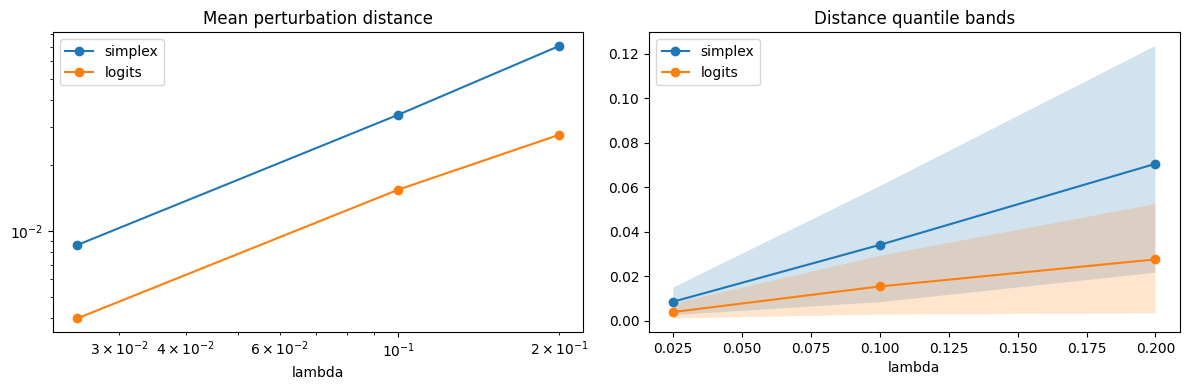

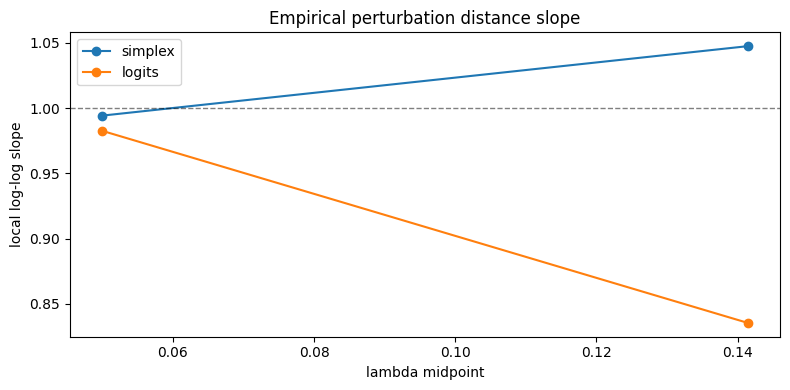

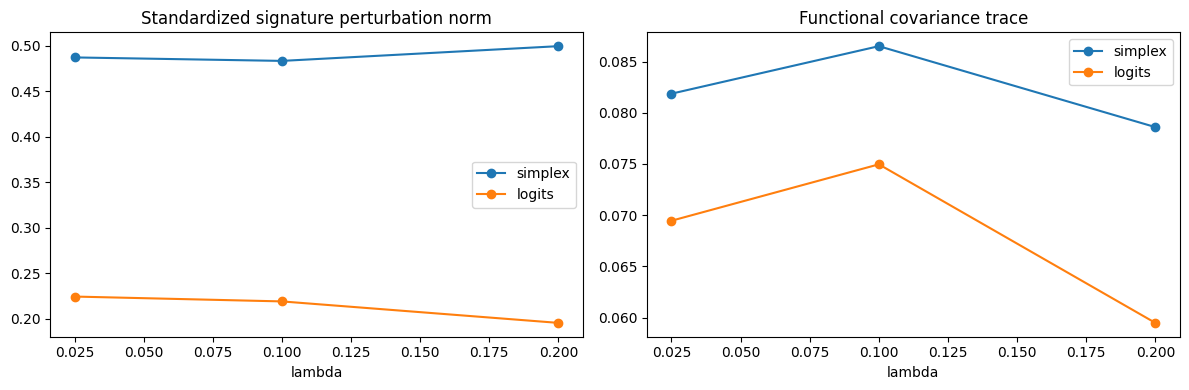

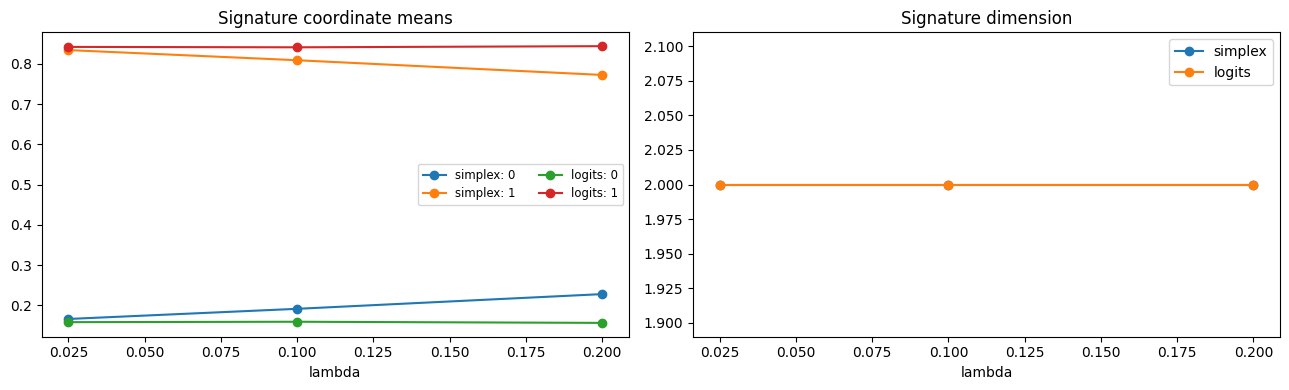

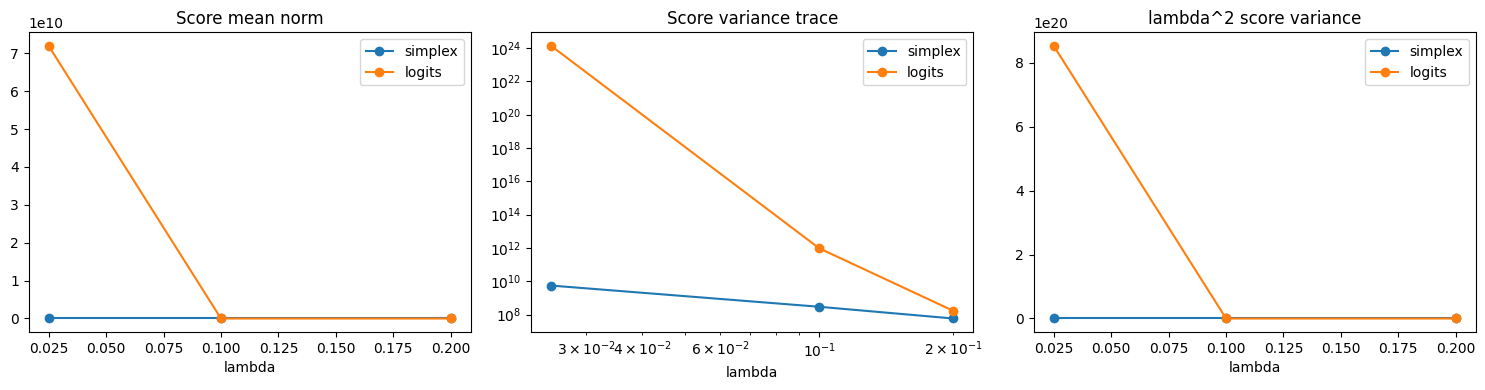

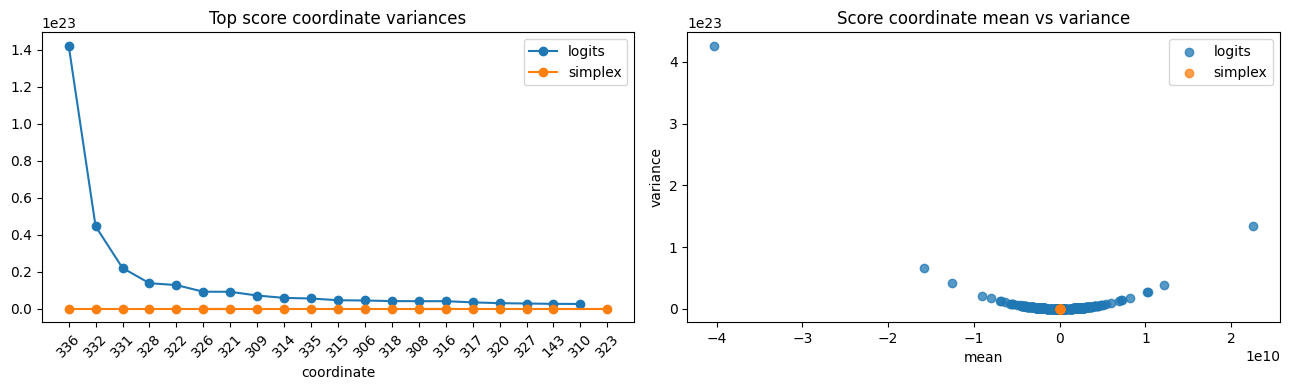

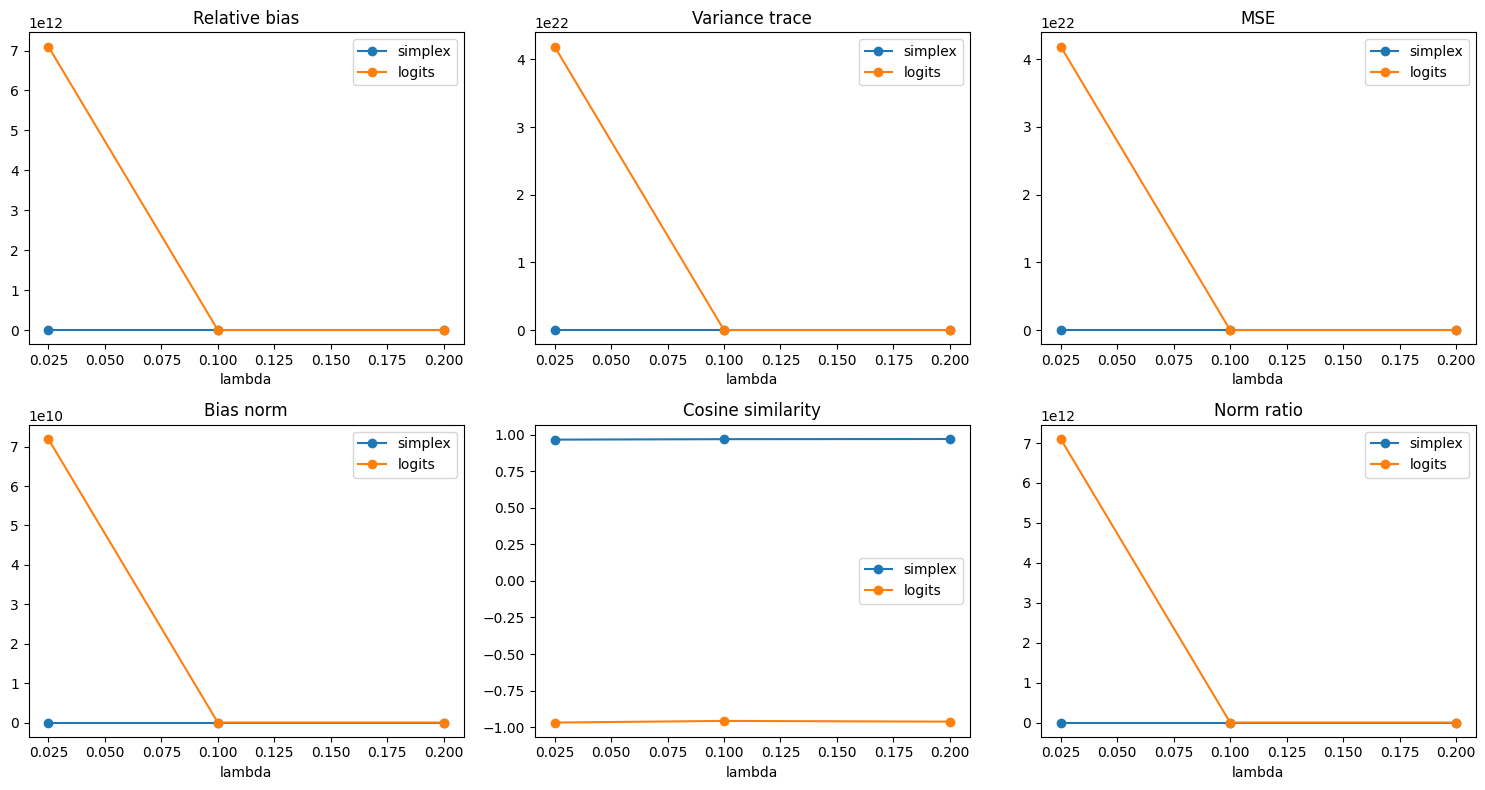

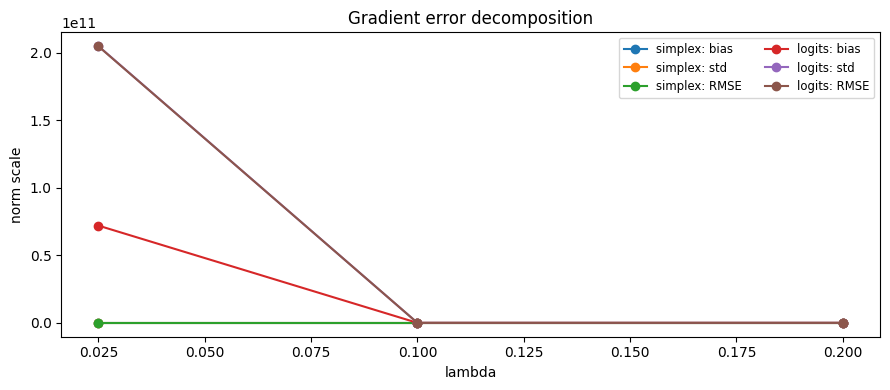

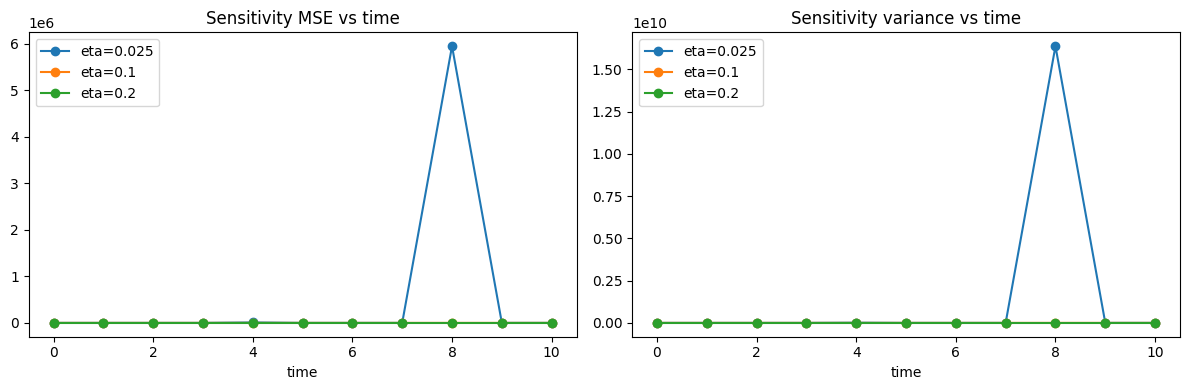

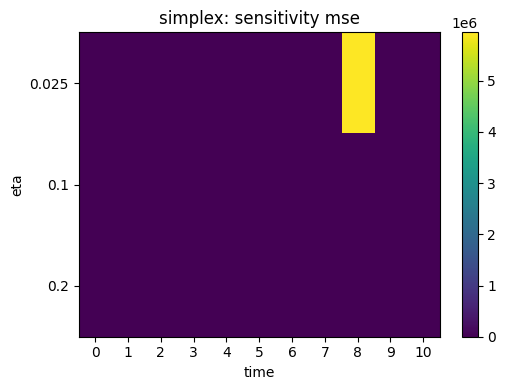

In [7]:
diagnostics = nh.load_diagnostic_data(bundle)
nh.plot_perturbation_geometry(diagnostics)
nh.plot_perturbation_slopes(diagnostics)
nh.plot_functional_law(diagnostics)
nh.plot_functional_signature_means(diagnostics)
nh.plot_score_validation(diagnostics)
nh.plot_score_coordinate_diagnostics(diagnostics)
nh.plot_gradient_validation(diagnostics)
nh.plot_gradient_error_decomposition(diagnostics)
nh.plot_sensitivity_validation(diagnostics)
nh.plot_sensitivity_heatmap(diagnostics)

## Scaling, Budget, And Optimization Summaries

Goal: measure how estimator quality and optimization performance change with simulator budget, auxiliary budget, horizon, and training time.

The budget heatmap varies main and auxiliary samples $(B,n)$ under the approximate cost model

$$
C\approx C_{main}B+C_{aux}n.
$$

The horizon plot studies how gradient error changes with $T$, and the optimization plots compare objective or cost gaps against iteration count, runtime, and simulator-call budget.

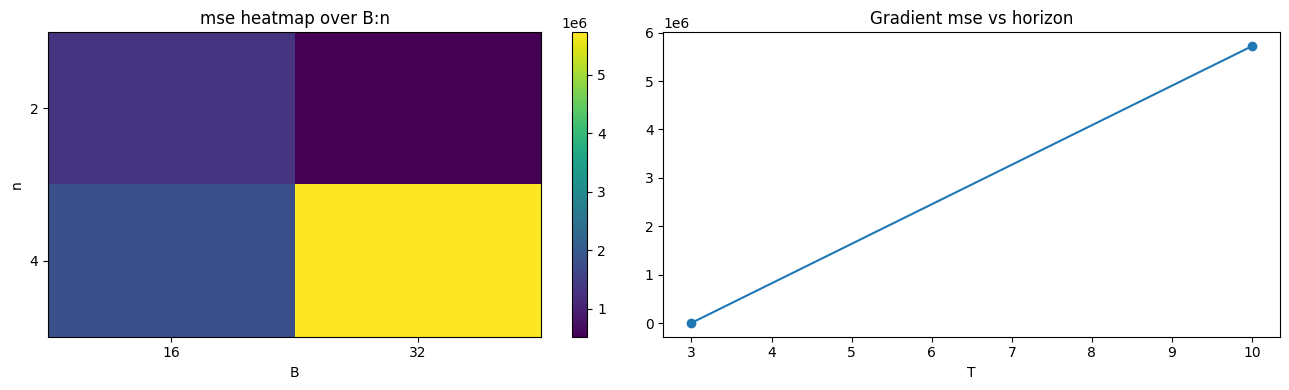

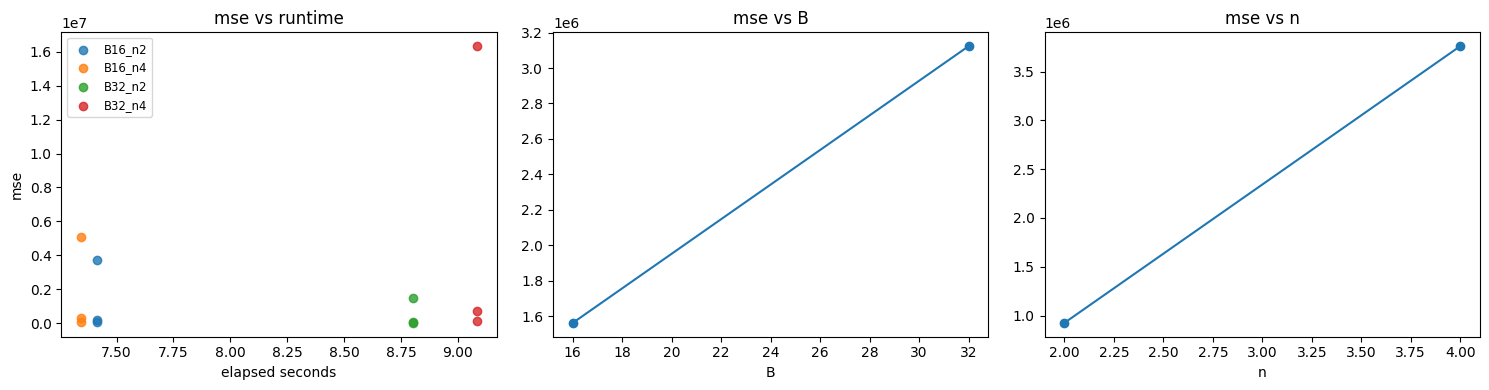

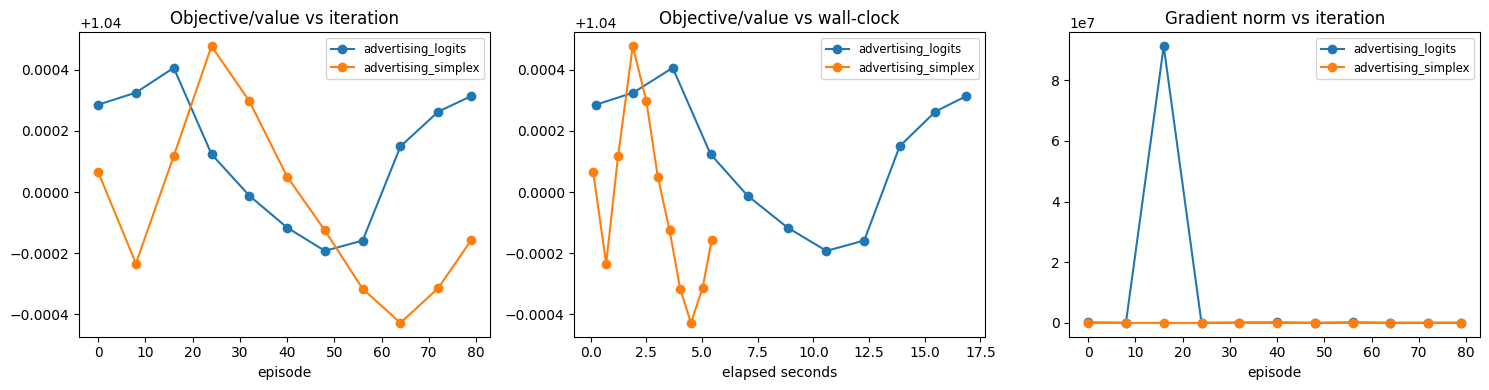

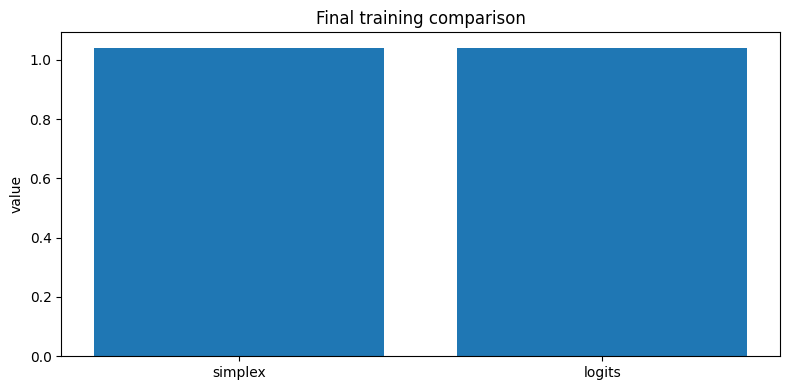

In [8]:
studies = nh.load_study_data(bundle)
grid_metrics = nh.load_study_grid_metrics(bundle)
optimization_history = nh.load_optimization_history(bundle)
nh.plot_budget_and_horizon(studies)
nh.plot_budget_pareto(studies, grid_metrics)
nh.plot_optimization_history(optimization_history)
nh.plot_optimization_summary(studies)

## Raw Tables For Custom Figures

Goal: expose the underlying CSV/JSON artifacts used by the plots so paper figures can be restyled or recomputed without rerunning training.

These tables are not new estimators. They are the saved values for population flows, policies, diagnostics, study grids, histories, and final metrics.

In [9]:
application["simplex"]["time_metrics"].head(), diagnostics["simplex"]["gradient"].head(), studies["budget"].head()

(           env  law_index  time  customer_fraction  advertising_rate  \
 0  advertising          0     0           0.500000          0.498626   
 1  advertising          0     1           0.599725          0.497913   
 2  advertising          0     2           0.699308          0.497149   
 3  advertising          0     3           0.798738          0.496388   
 4  advertising          0     4           0.898015          0.495683   
 
    advertising_cost  population_gain  
 0          0.074794         0.500000  
 1          0.074687         0.599725  
 2          0.074572         0.699308  
 3          0.074458         0.798738  
 4          0.074352         0.898015  ,
    lambda  replications  estimate_norm  variance_trace  \
 0   0.025             8     371.791821    1.850806e+07   
 1   0.100             8     150.537966    7.869979e+05   
 2   0.200             8      99.413498    1.266404e+05   
 
    covariance_largest_eigenvalue  oracle_norm   bias_norm  relative_bias  \
 0  